### Readme
This notebook is for pupil segmentation in EEG data.<br>
There are multiple video files.

In [53]:
from lib.input_output import h5py_read
from lib.input_output import h5py_write
from lib.utils import correct_outliers
from lib.visualization import plot_traces
from lib.visualization import plot_trace_single
from lib.visualization import show_one_image
from lib.visualization import show_images
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats
from tifffile import imread
from tifffile import imwrite
from tqdm import tqdm

import cv2
import glob
import numpy as np
import os
import pandas as pd
import scipy
import sys

In [54]:
import matplotlib_inline.backend_inline

# pdf format did not show in iPython notebook
# matplotlib_inline.backend_inline.set_matplotlib_formats('pdf')
# matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

matplotlib_inline.backend_inline.set_matplotlib_formats('png', 'retina')
plt.rcParams["font.family"] = "Arial"
cm = 1 / 2.54  # centimeters in inches

ABBRE = {"Spontaneous": "st", "MovingBar": "mb",
    "FlashGrating": "fg", "MovingGrating": "mg"}

In [88]:
root_folder = '/home/wrx/EEG/'
date = '20250814'
ID = 'X6'
treatment = 'DOM'

date_folder = os.path.join(root_folder, date, ID)
print(f'date_folder:{date_folder}')

behavioral_folder = os.path.join(date_folder, 'Behavioral')
print(f'Behavioral folder: {behavioral_folder}')

treatment_folder = os.path.join(behavioral_folder, treatment)

if not os.path.exists(treatment_folder):
    raise FileNotFoundError(f"Directory {treatment_folder} does not exist.")

# convert the pixels into microns @senzai2022cognitive
# 128 pixels = 3.2 microns
# microns_per_pixel = 3.2 / 128

date_folder:/home/wrx/EEG/20250814/X6
Behavioral folder: /home/wrx/EEG/20250814/X6/Behavioral


Select the video

In [56]:
stimli_name = ['Spontaneous',
 'MovingBar',
 'FlashGrating',
 'MovingGrating']

In [89]:
avi_files = glob.glob(os.path.join(treatment_folder, '*.avi'))
print(f"Found {len(avi_files)} AVI files in {treatment_folder}.")
pprint(avi_files)

Found 4 AVI files in /home/wrx/EEG/20250814/X6/Behavioral/DOM.
['/home/wrx/EEG/20250814/X6/Behavioral/DOM/2025-08-14_FlashGrating.avi',
 '/home/wrx/EEG/20250814/X6/Behavioral/DOM/2025-08-14_MovingBar.avi',
 '/home/wrx/EEG/20250814/X6/Behavioral/DOM/2025-08-14_MovingGrating.avi',
 '/home/wrx/EEG/20250814/X6/Behavioral/DOM/2025-08-14_Spontaneous.avi']


In [102]:
# selecting the video file
# video_path = avi_files[6]

i = 3
print(f'Selecting video for stimulus: {stimli_name[i]}')
video_path = [file for file in avi_files if stimli_name[i] in file][0]
print(f'Video path selected: {video_path}')

basename = os.path.basename(video_path)
basename = os.path.splitext(basename)[0]
print(f"Basename without extension: {basename}")

Selecting video for stimulus: MovingGrating
Video path selected: /home/wrx/EEG/20250814/X6/Behavioral/DOM/2025-08-14_MovingGrating.avi
Basename without extension: 2025-08-14_MovingGrating


Preview the first frame of a video

Video codec: 1196444237
Frames per second (FPS): 10.0
The video has 3 channels.


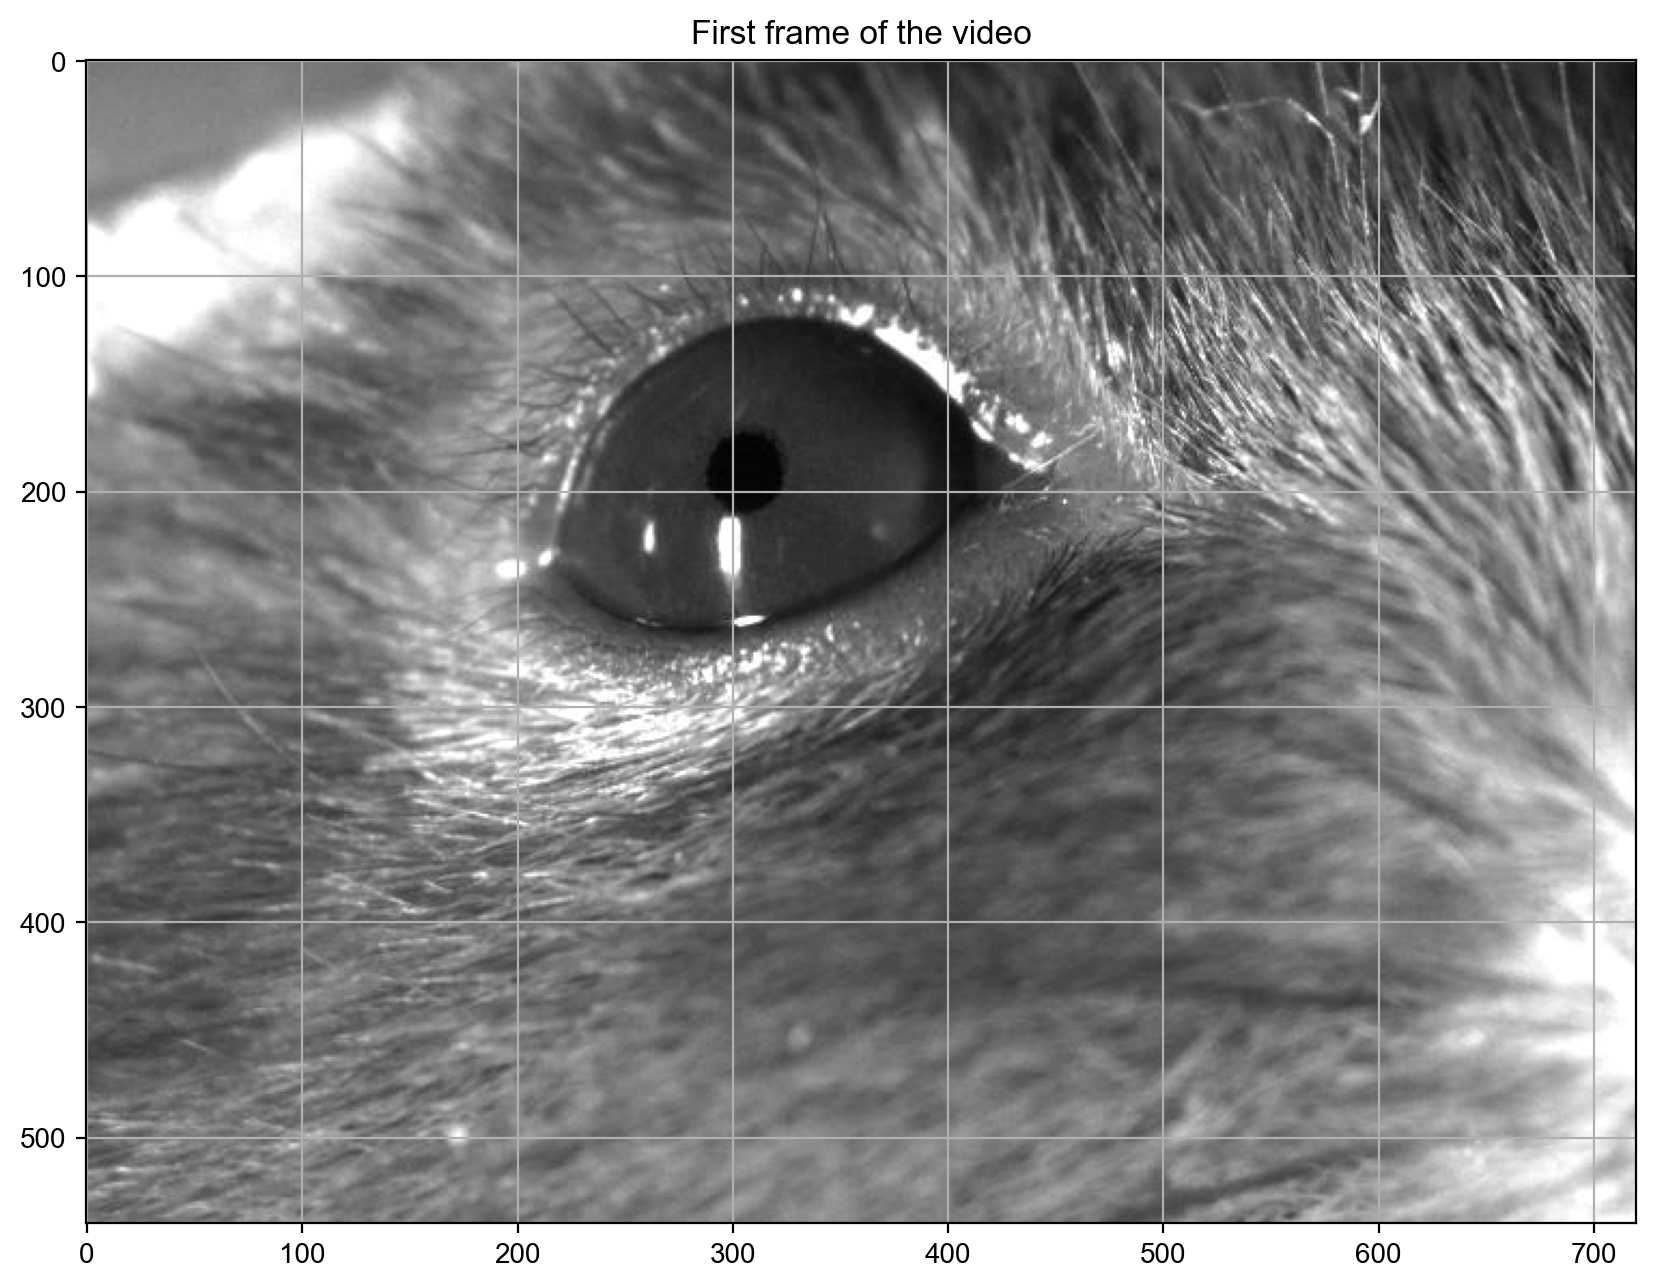

In [59]:
# read the video
cap = cv2.VideoCapture(video_path)

# get the compression codec
fourcc = int(cap.get(cv2.CAP_PROP_FOURCC))
print(f"Video codec: {fourcc}")

# get the fps (frames per second)
fps = cap.get(cv2.CAP_PROP_FPS)
print(f"Frames per second (FPS): {fps}")

# get the first frame
ret, frame = cap.read()
cap.release()

n_channels = frame.shape[2]
print(f'The video has {n_channels} channels.')

frame = frame[:, :, 0] # the video is grayscale, so choose one channel
show_one_image(frame, grid=True, figsize=(10, 10),
    title='First frame of the video')

Set the cropping rectangle

Shape of the pupil image: (200, 300)


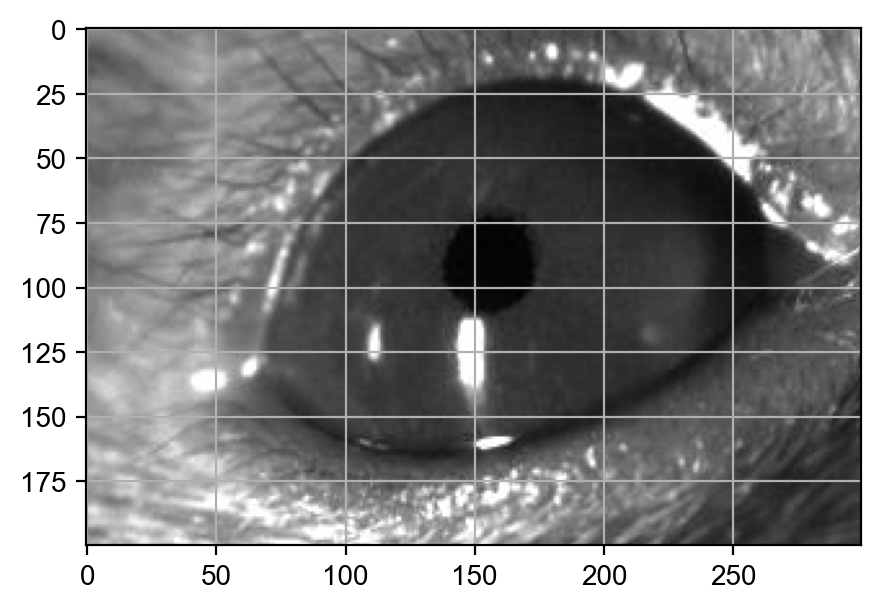

In [60]:
ops_path = os.path.join(date_folder, f"{basename}_ops.npy")
if os.path.exists(ops_path):
    print(f"Loading ops from {ops_path}")
    ops = np.load(ops_path, allow_pickle=True).item()
    left, top, right, bottom = ops["crop"]["left"], ops["crop"]["top"], \
        ops["crop"]["right"], ops["crop"]["bottom"]
    print(f"Crop coordinates: {left}, {top}, {right}, {bottom}")
else:
    left, top, right, bottom = 150, 100, 450, 300

pupil_image = frame[top:bottom, left:right]
print("Shape of the pupil image:", pupil_image.shape)
show_one_image(pupil_image, grid=True)

In [61]:
# save the pupil image as a tif reference
pupil_image_path = os.path.join(behavioral_folder, f"pupil_reference.tif")
print(f"Saving pupil image to {pupil_image_path}")
imwrite(pupil_image_path, pupil_image)

Saving pupil image to /home/wrx/EEG/20250814/X6/Behavioral/pupil_reference.tif


### Set parameters

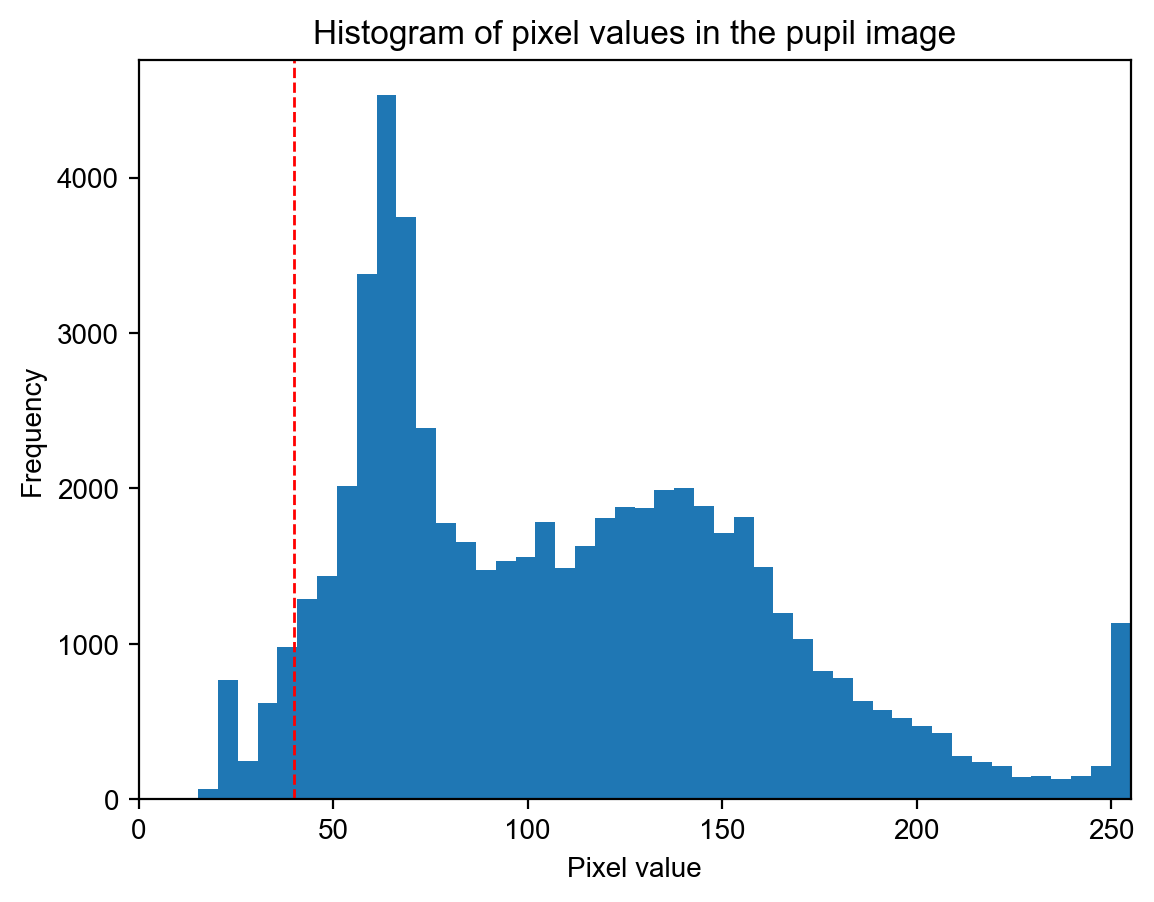

In [71]:
fig, ax = plt.subplots()
ax.hist(pupil_image.flatten(), bins=50, range=(0, 255))
ax.set_title("Histogram of pixel values in the pupil image")
ax.set_xlabel("Pixel value")
ax.set_ylabel("Frequency")
ax.axvline(ops["threshold"], color='r', linestyle='dashed', linewidth=1)
ax.set_xlim(0, 255)
plt.show()

In [70]:
ops = {"crop":{"top": top, "left": left, "bottom": bottom, "right": right,}
}

ops["threshold"] = 40 # the pixel intensity threshold for detect dark pupil
ops["contour_length"] = (20, 500) # pixel length of pupil contour

# save the ops
# if os.path.exists(date_folder):
    # raise Warning(f"Folder already exists: {date_folder}")
ops_path = os.path.join(behavioral_folder, f"Ops.npy")
print(f"Saving ops to {ops_path}")
np.save(ops_path, ops)

Saving ops to /home/wrx/EEG/20250814/X6/Behavioral/Ops.npy


### Detetct the pupil and save the image

In [65]:
from lib.detection import pupil_detection

Test the pupil detection function and parameters

In [ ]:
ellipse, overlay_img, mean = pupil_detection(pupil_image, 
    ops=ops,
    test=True,)

Run the detection to process the video

Processing video: /home/wrx/EEG/20250814/X6/Behavioral/DOM/2025-08-14_MovingGrating.avi
Total number of frames in the video: 3899


  0%|          | 0/3899 [00:00<?, ?it/s]

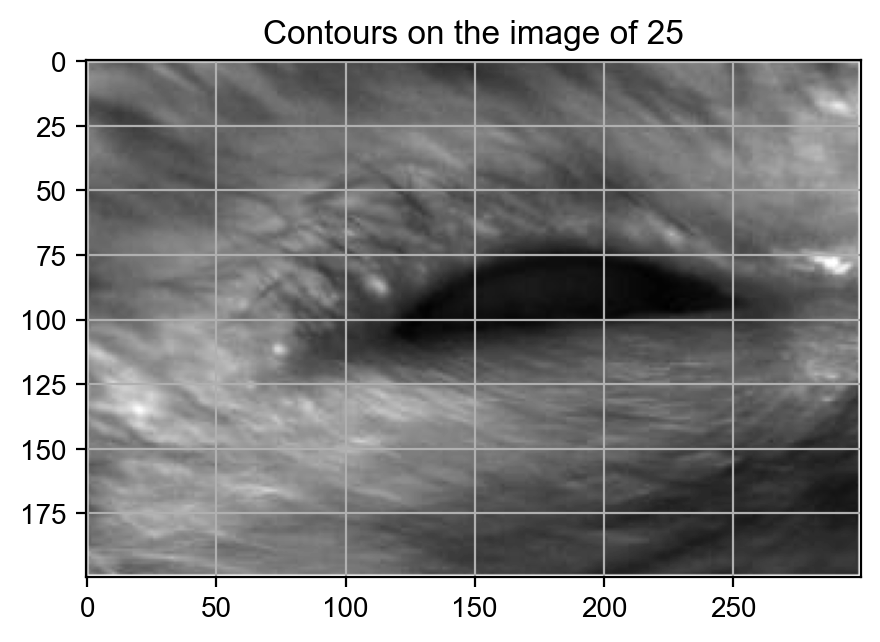

  2%|▏         | 63/3899 [00:00<00:26, 143.32it/s]

The lengths of the contours: [996]


  4%|▍         | 171/3899 [00:00<00:13, 275.05it/s]

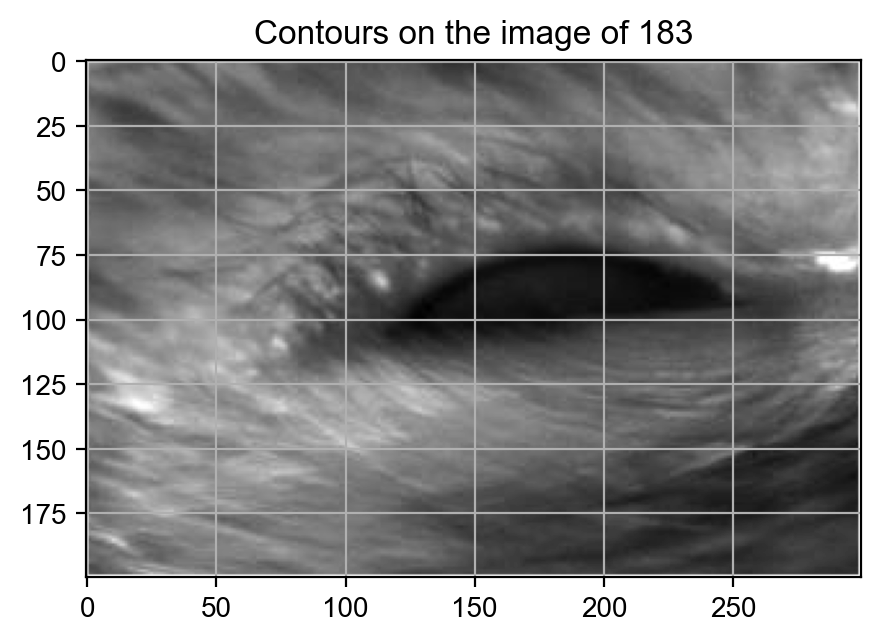

  6%|▌         | 241/3899 [00:01<00:18, 201.28it/s]

The lengths of the contours: [996]


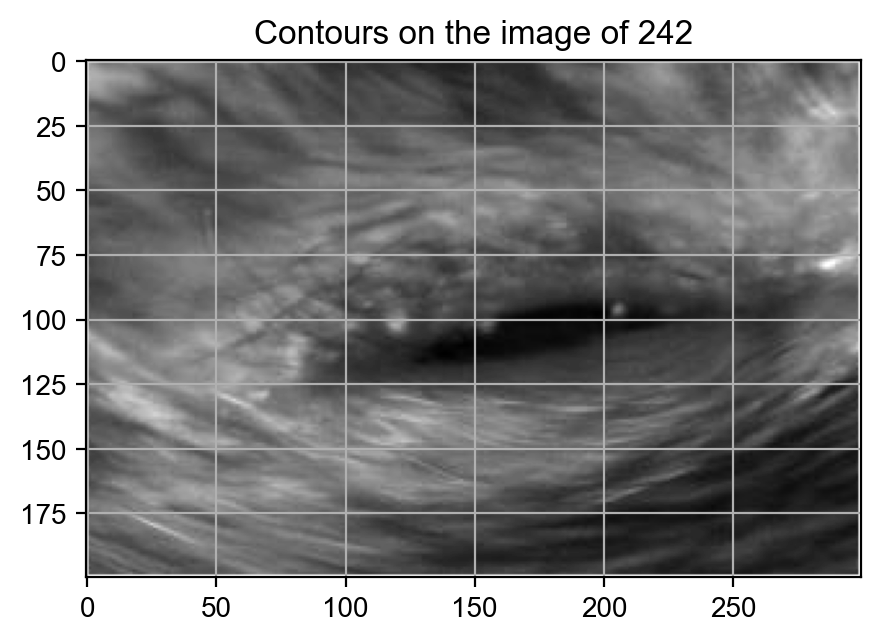

  8%|▊         | 306/3899 [00:01<00:20, 178.39it/s]

The lengths of the contours: [996]


 68%|██████▊   | 2642/3899 [00:08<00:03, 354.15it/s]

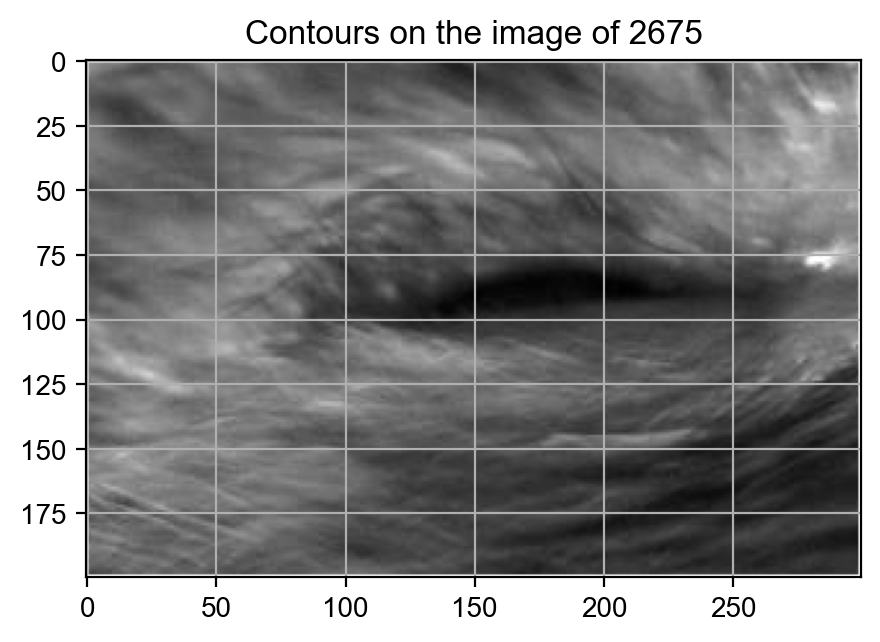

 70%|██████▉   | 2710/3899 [00:08<00:05, 219.66it/s]

The lengths of the contours: [996]


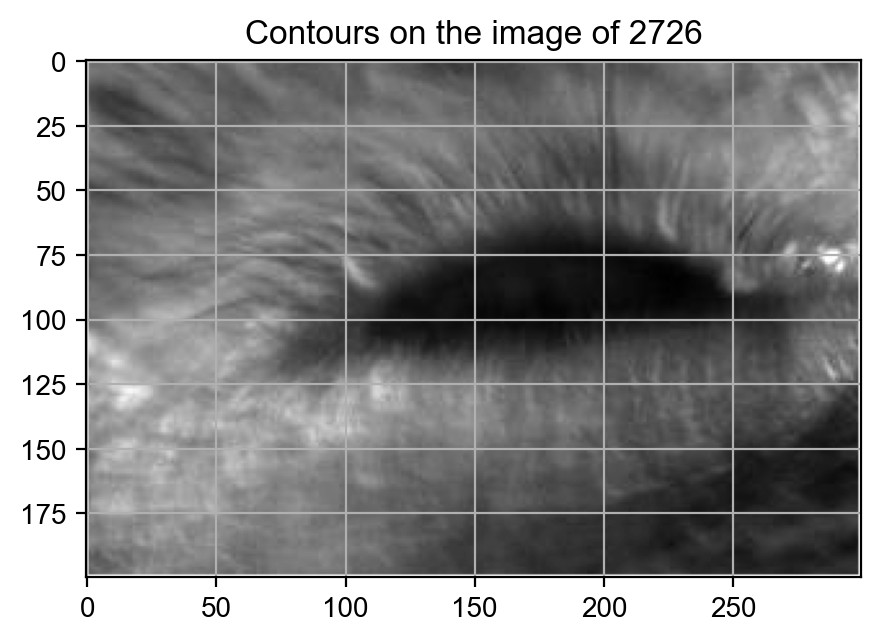

 71%|███████   | 2775/3899 [00:09<00:06, 179.50it/s]

The lengths of the contours: [996]


 72%|███████▏  | 2811/3899 [00:09<00:05, 212.68it/s]

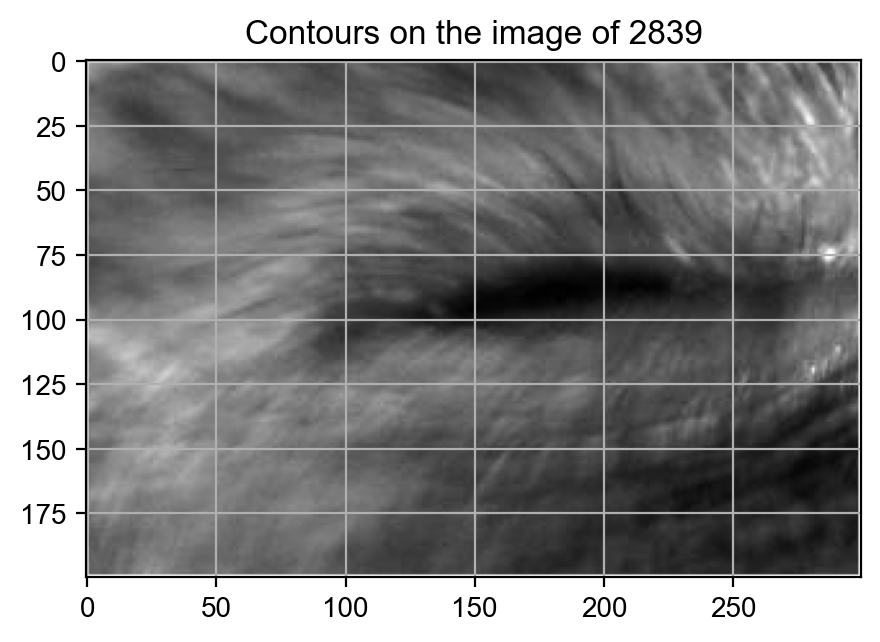

 74%|███████▍  | 2876/3899 [00:10<00:06, 159.85it/s]

The lengths of the contours: [996]


 76%|███████▌  | 2947/3899 [00:10<00:04, 223.95it/s]

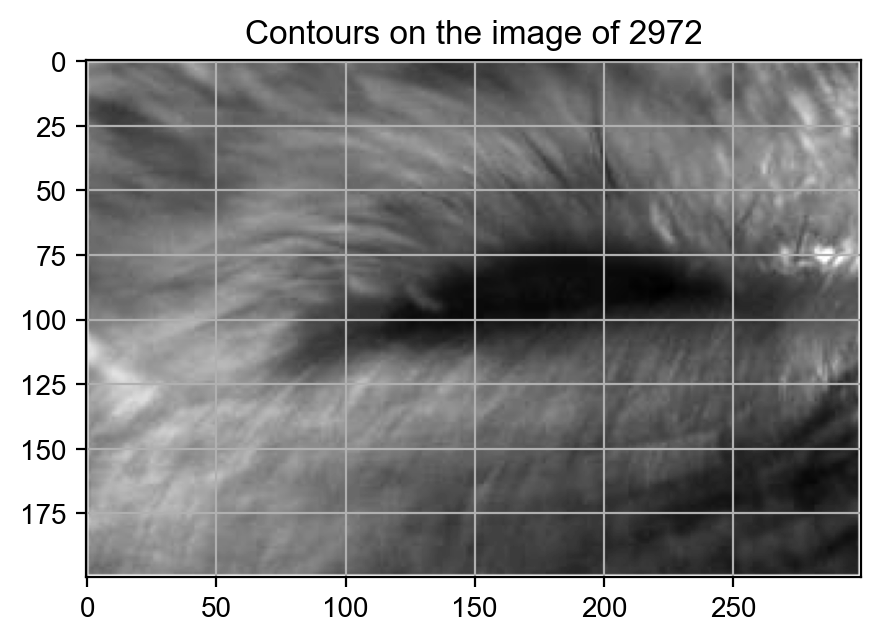

 77%|███████▋  | 3013/3899 [00:10<00:04, 187.80it/s]

The lengths of the contours: [996]


 79%|███████▉  | 3085/3899 [00:10<00:03, 249.32it/s]

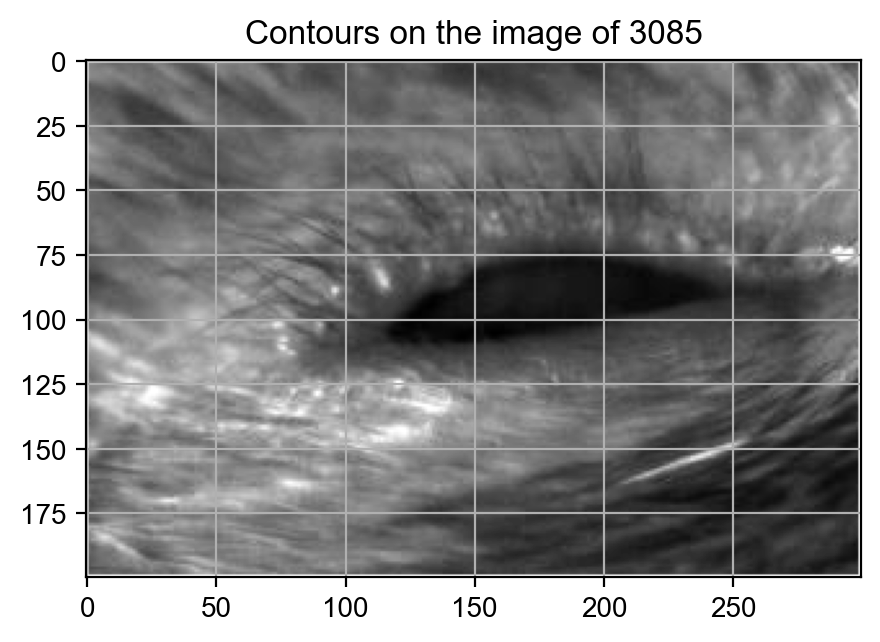

 81%|████████  | 3152/3899 [00:11<00:03, 194.35it/s]

The lengths of the contours: [996]


 84%|████████▎ | 3260/3899 [00:11<00:02, 277.81it/s]

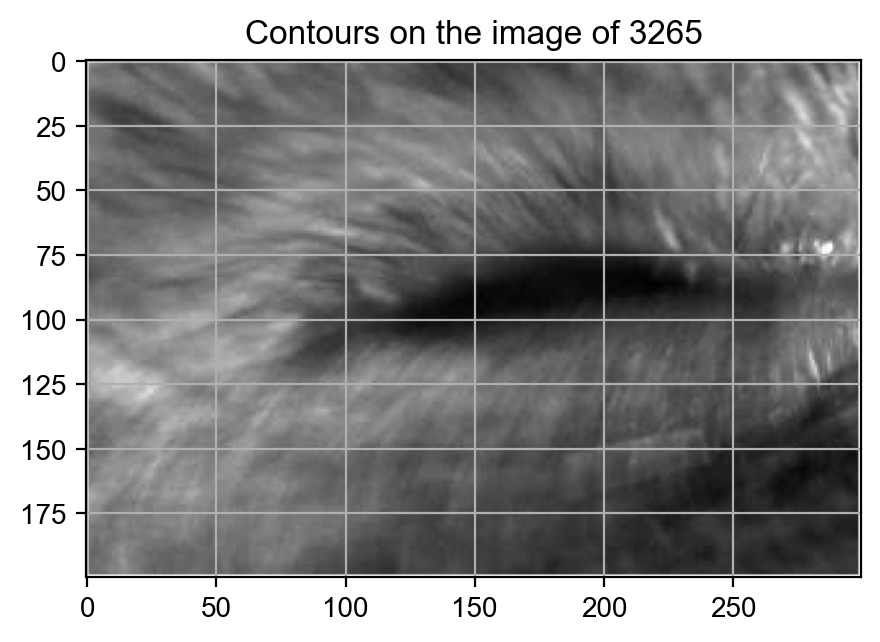

 85%|████████▌ | 3329/3899 [00:12<00:02, 205.55it/s]

The lengths of the contours: [996]


100%|██████████| 3899/3899 [00:13<00:00, 283.23it/s]


Shape of the stack: (3899, 200, 300)
Writing overlay video to: /home/wrx/EEG/20250814/X6/Behavioral/DOM/2025-08-14_MovingGrating.mp4


100%|██████████| 3899/3899 [00:02<00:00, 1629.48it/s]


In [103]:
print(f"Processing video: {video_path}")
cap = cv2.VideoCapture(video_path)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Total number of frames in the video: {frame_count}")
# if frame_count > 100:
#     frame_count = 100
# print(f"Processing {n_frames} frames of the video.")

pupil_positions = []
stack = []
pupil_mean = []
for i in tqdm(range(frame_count)):
    ret, frame = cap.read()
    if not ret:
        print(f"Failed to read frame {i}.")
        break
    frame = frame[:, :, 0]  # use the first channel (grayscale)
    frame = frame[top:bottom, left:right]
    ellipse, overlay_img, mean = pupil_detection(frame,
        ops=ops,
        test=False, index=i)
    pupil_mean.append(mean)
    pupil_positions.append(ellipse)  # center of the ellipse
    stack.append(overlay_img)
cap.release()

stack = np.array(stack)
print(f"Shape of the stack: {stack.shape}")

# write the overlay image as mp4 video
output_video_path = os.path.join(treatment_folder, f"{basename}.mp4")
print(f"Writing overlay video to: {output_video_path}")
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_video_path, fourcc, 30.0,
    (stack.shape[2], stack.shape[1]), isColor=False)
for i in tqdm(range(stack.shape[0])):
    out.write(stack[i])
out.release()

### Save the pupil position results

In [104]:
print("Length of pupil positions:", len(pupil_positions))
pupil_x = [p[0][0] if p is not None else 0 for p in pupil_positions]
pupil_y = [p[0][1] if p is not None else 0 for p in pupil_positions]
pupil_areas = [np.pi*p[1][0]*p[1][1] if p is not None else 0 for p in \
    pupil_positions]

pupil_areas = np.array(pupil_areas)
pupil_mean = np.array(pupil_mean)
pupil_mean = pupil_mean.astype(np.float64)
pupil_x = np.array(pupil_x)
pupil_y = np.array(pupil_y)

stimulus_name = str.split(basename, '_')[1]
print(f'stimulus_name: {stimulus_name}')

results_path = os.path.join(treatment_folder, f"results.hdf5")
print("Saving results to:", results_path)
result = {ABBRE[stimulus_name]: {
    "area": pupil_areas,
    "mean": pupil_mean,
    "x": pupil_x,
    "y": pupil_y,
}}
print(result.keys())

h5py_write(results_path, result)

Length of pupil positions: 3899
stimulus_name: MovingGrating
Saving results to: /home/wrx/EEG/20250814/X6/Behavioral/DOM/results.hdf5
dict_keys(['mg'])


### Calculate the STD of the drawed movie

Number of frames in the video: 3899
Frame height: 200, Frame width: 300


100%|██████████| 3899/3899 [00:00<00:00, 8689.04it/s]


Shape of the movie: (3899, 200, 300)


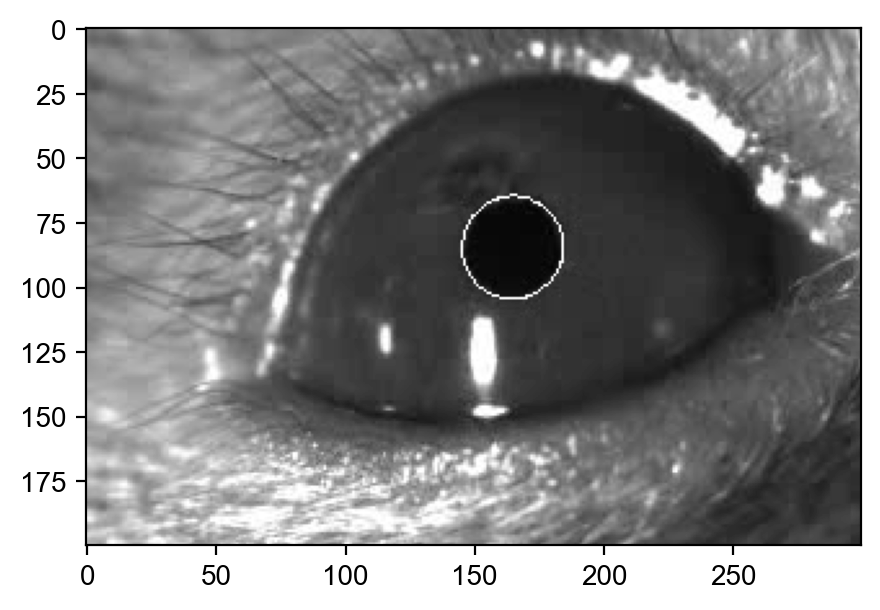

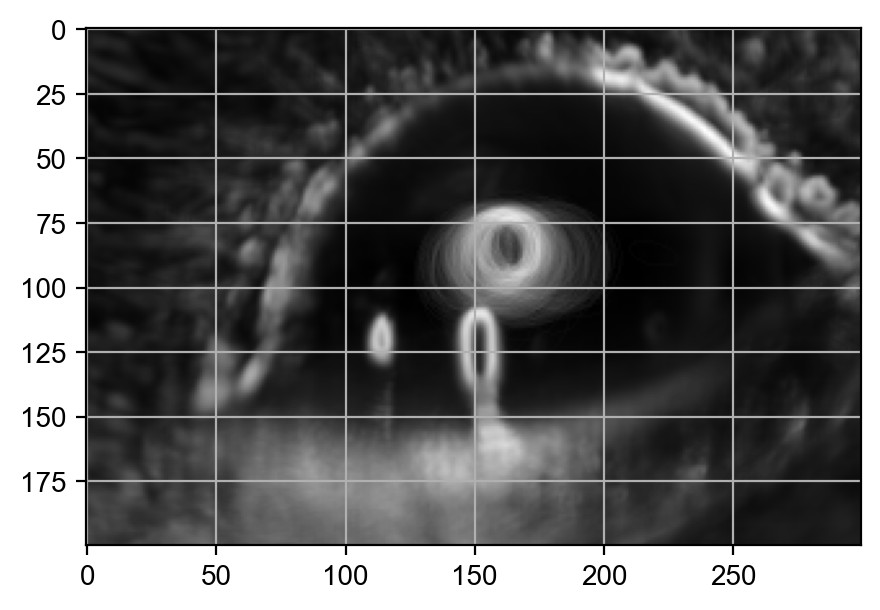

In [105]:
# read the video
cap = cv2.VideoCapture(output_video_path)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"Number of frames in the video: {frame_count}")

frame_height, frame_width = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)), \
    int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
print(f"Frame height: {frame_height}, Frame width: {frame_width}")

# frame_count = 100
movie = np.zeros((frame_count, frame_height, frame_width), dtype=np.uint8)
for i in tqdm(range(frame_count)):
    ret, frame = cap.read()
    movie[i] = frame[:, :, 0] # the video is grayscale, so choose one channel
cap.release()
print("Shape of the movie:", movie.shape)

show_one_image(movie[0], grid=False)

movie_std = movie.std(axis=0)
show_one_image(movie_std, grid=True)
# save the standard deviation image as a tif reference
std_image_path = os.path.join(treatment_folder, f"{basename}_STD.tif")
imwrite(std_image_path, movie_std.astype(np.uint16))

### Read the results

In [ ]:
if 'result' not in locals():
    print(f"Loading results from {date_folder}")
   
    h5_file = glob.glob(os.path.join(date_folder, f"*_results.hdf5"))[0]
    print(f"Found results file: {h5_file}")
    result = h5py_read(h5_file)

### Plot the trace

In [ ]:
threshold = 6
x_corrected = correct_outliers(pupil_x, threshold=threshold)
y_corrected = correct_outliers(pupil_y, threshold=threshold)

data = np.array([x_corrected, y_corrected]).T
print(data.shape)
plot_traces(data, data_rate=fps, labels=["x", "y"], 
    title="Corrected Pupil position", ylabel="Position (pixel)",
    figsize=(15*cm, 5*cm))

In [ ]:
pupil_areas = correct_outliers(result['mb']['area'])
# pupil_areas = pupil_areas * microns_per_pixel**2  # convert to microns^2

In [ ]:
title = f"{ID} {date} Pupil area"

# vlines = [dom_injection_time]
plot_trace_single(pupil_areas, data_rate=fps,
    title=title, ylabel="Area (mm²)", color='blue',
    figsize=(15*cm, 5*cm),
    # vlines=vlines, vline_labels=['DOM injection'],
    )

In [ ]:
title = f"{ID} {date} Pupil area Saline (zoom in)"
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plot_trace_single(pupil_areas[:9000], data_rate=fps,
    title=title, ylabel="Area (mm²)",
    color=colors[0], label='Saline',
    figsize=(15*cm, 5*cm))

title = f"{ID} {date} Pupil area DOM (zoom in)"
plot_trace_single(pupil_areas[-9000:], data_rate=fps,
    title=title, ylabel="Area (mm²)",
    color=colors[1], label='DOM',
    figsize=(15*cm, 5*cm))

### Compare the saline and DOM conditions

In [106]:
saline_results_path = os.path.join(date_folder, 'Behavioral', 'Saline',
    'results.hdf5')
saline_results = h5py_read(saline_results_path)
dom_results_path = os.path.join(date_folder, 'Behavioral', 'DOM',
    'results.hdf5')
dom_results = h5py_read(dom_results_path)
print(saline_results.keys())
print(dom_results.keys())

scale = 16 / 850 # 850 pixels = 16 mm, mm per pixel = 0.018823529411764705

dict_keys(['fg', 'mb', 'mg', 'st'])
dict_keys(['fg', 'mb', 'mg', 'st'])


In [107]:
saline_area_mean = []
saline_area = []
# There are some stimuli that not available, 
# so use the keys rather than range(n_stim)
for key in saline_results.keys():
    print(f"Processing {key}...")
    area_raw = saline_results[key]["area"] * scale**2
    area_corrected = correct_outliers(area_raw)
    saline_area.append(area_corrected)
    area_mean = np.mean(area_corrected)
    saline_area_mean.append(area_mean)
# print(saline_area_mean)
saline_area_mean = np.array(saline_area_mean)

dom_area_mean = []
dom_area = []
for key in dom_results.keys():
    area_raw = dom_results[key]["area"] * scale**2
    area_corrected = correct_outliers(area_raw)
    dom_area.append(area_corrected)
    area_mean = np.mean(area_corrected)
    dom_area_mean.append(area_mean)
# print(dom_area_mean)
dom_area_mean = np.array(dom_area_mean)

Processing fg...
Processing mb...
Processing mg...
Processing st...


In [108]:
saline_area = np.concatenate(saline_area)
dom_area = np.concatenate(dom_area)

Max area: 4.785023508923504


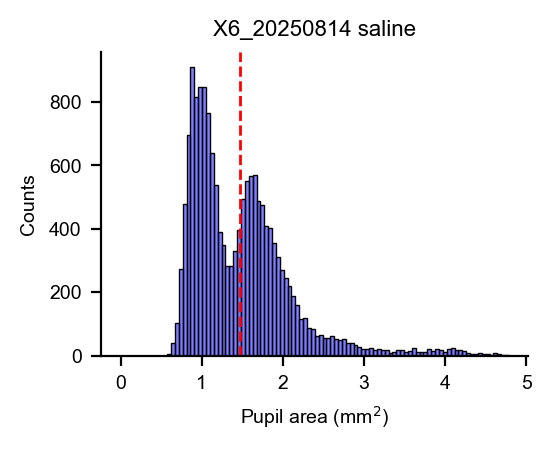

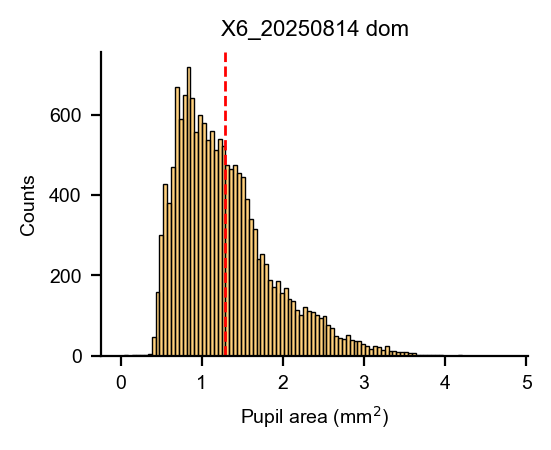

In [109]:
from lib.visualization import hist_customize

max = np.max((saline_area.max(), dom_area.max()))
print(f"Max area: {max}")
xlim  = (0, max)

title = f"{ID}_{date} saline"
hist_customize(saline_area, bins=100, color='blue',
    figsize=(7*cm, 5*cm), xlabel='Pupil area (mm$^2$)', ylabel='Counts',
    title=title, vlines=[saline_area.mean()], xlim=xlim)

title = f"{ID}_{date} dom"
hist_customize(dom_area, bins=100, color='orange',
    figsize=(7*cm, 5*cm), xlabel='Pupil area (mm$^2$)', ylabel='Counts',
    title=title, vlines=[dom_area.mean()], xlim=xlim)

### Summary the data

In [ ]:
results_path = os.path.join(date_folder, "results.hdf5")
print("Saving results to:", results_path)

In [ ]:
from lib.input_output import h5py_read

In [ ]:
results = h5py_read(results_path)
print("Keys in the results:", results.keys())